# Mini Project: Dry Bean Type Classification
### Multiclass Classification using Supervised Learning

## Task 1: Import and Load the Data

In [30]:
# Task 1: Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample

# Load dataset
df = pd.read_excel('Beans_Multiclass_Classification.xlsx')

print('Shape:', df.shape)
print()
print('--- HEAD ---')
print(df.head())
print()
print('--- INFO ---')
df.info()
print()
print('--- Duplicates ---')
print(df.duplicated().sum())
print()
print('--- DESCRIBE ---')
print(df.describe())


Shape: (13611, 17)

--- HEAD ---
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class

## Task 2: Exploratory Data Analysis (EDA)

0



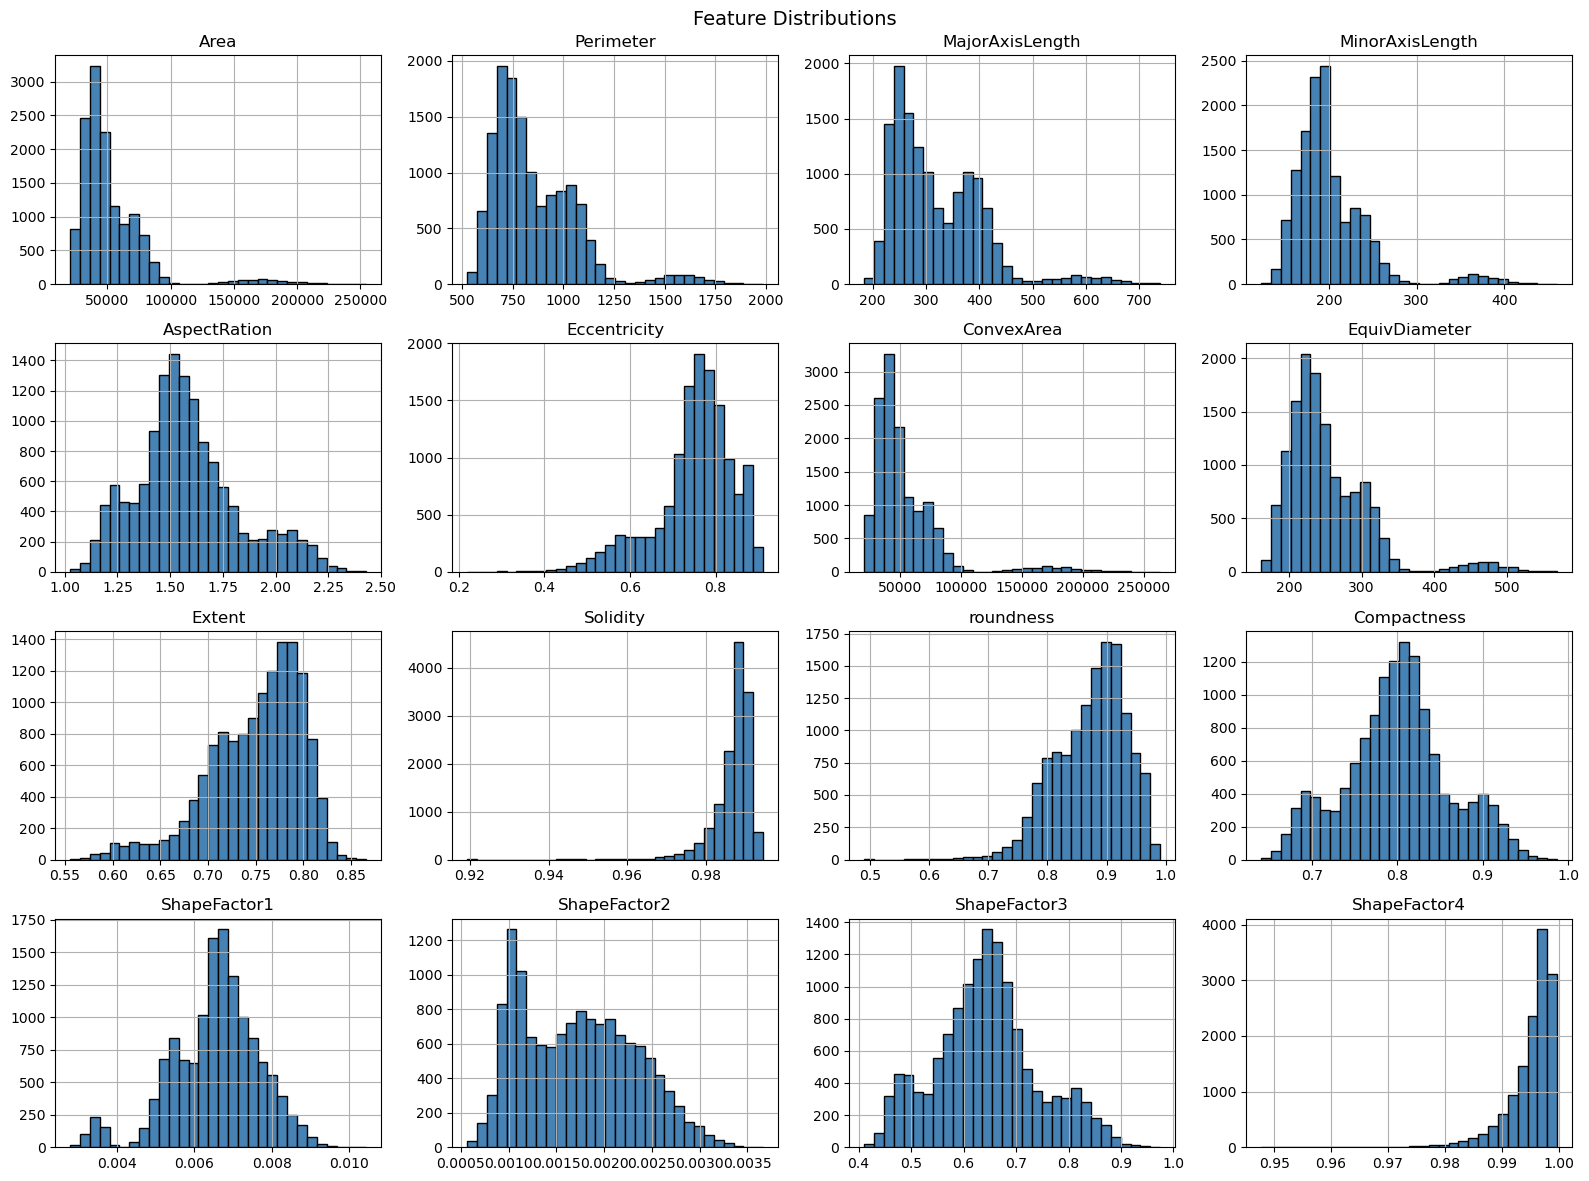

In [8]:
# Task 2: EDA - Feature distributions (histograms)
# ================================== Remove duplicates
df = df.drop_duplicates()
print(df.duplicated().sum())
print()

features = df.drop('Class', axis=1).columns.tolist()

df[features].hist(figsize=(16, 12), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

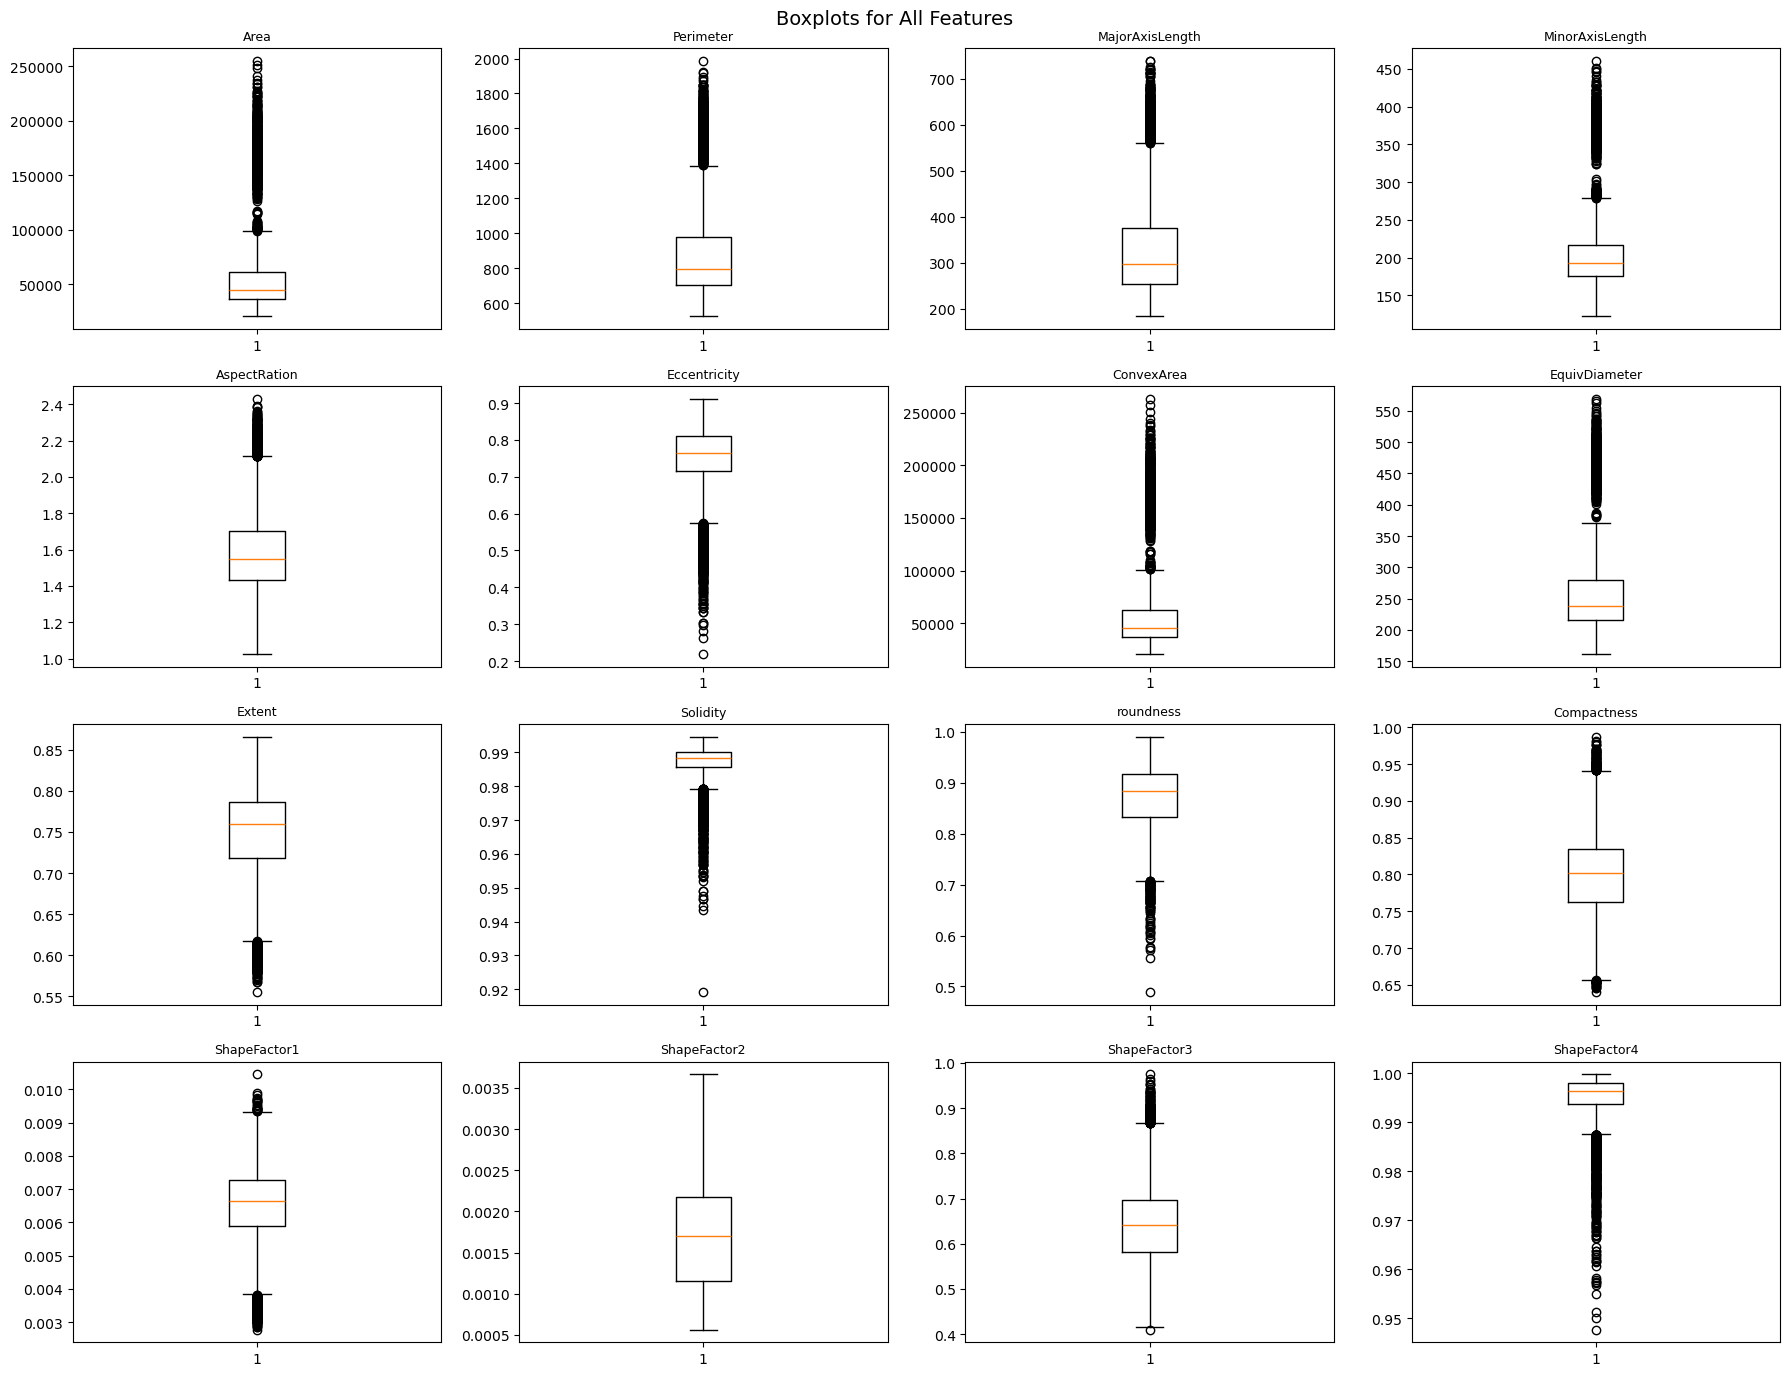

In [9]:
# Task 2: Boxplots for each feature
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots for All Features', fontsize=14)
plt.tight_layout()
plt.show()

Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class %:
Class
DERMASON    0.26
SIRA        0.19
SEKER       0.15
HOROZ       0.14
CALI        0.12
BARBUNYA    0.10
BOMBAY      0.04
Name: proportion, dtype: float64


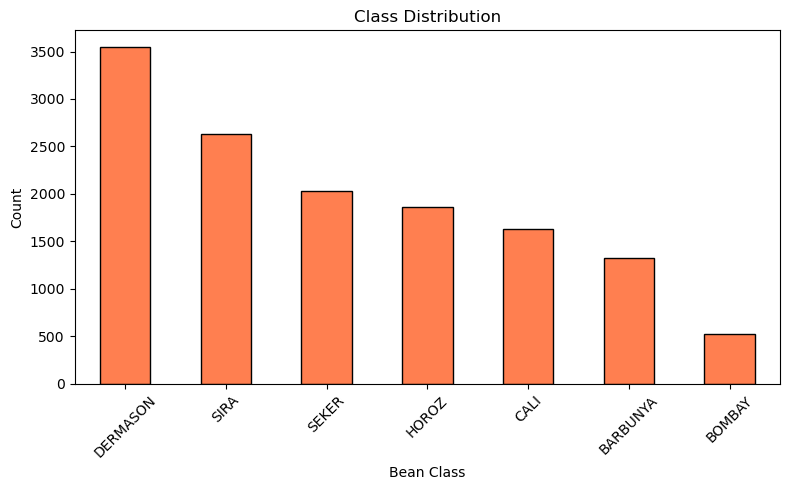


Observation: BOMBAY class (~522) is the minority class. Mild imbalance exists.


In [12]:
# Task 2: Class distribution - check for imbalance
class_counts = df['Class'].value_counts()
print('Class Distribution:')
print(class_counts)
print()
print('Class %:')
#print((class_counts / len(df) * 100).round(2))
print(df['Class'].value_counts(normalize = True).round(2))

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Bean Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nObservation: BOMBAY class (~522) is the minority class. Mild imbalance exists.')

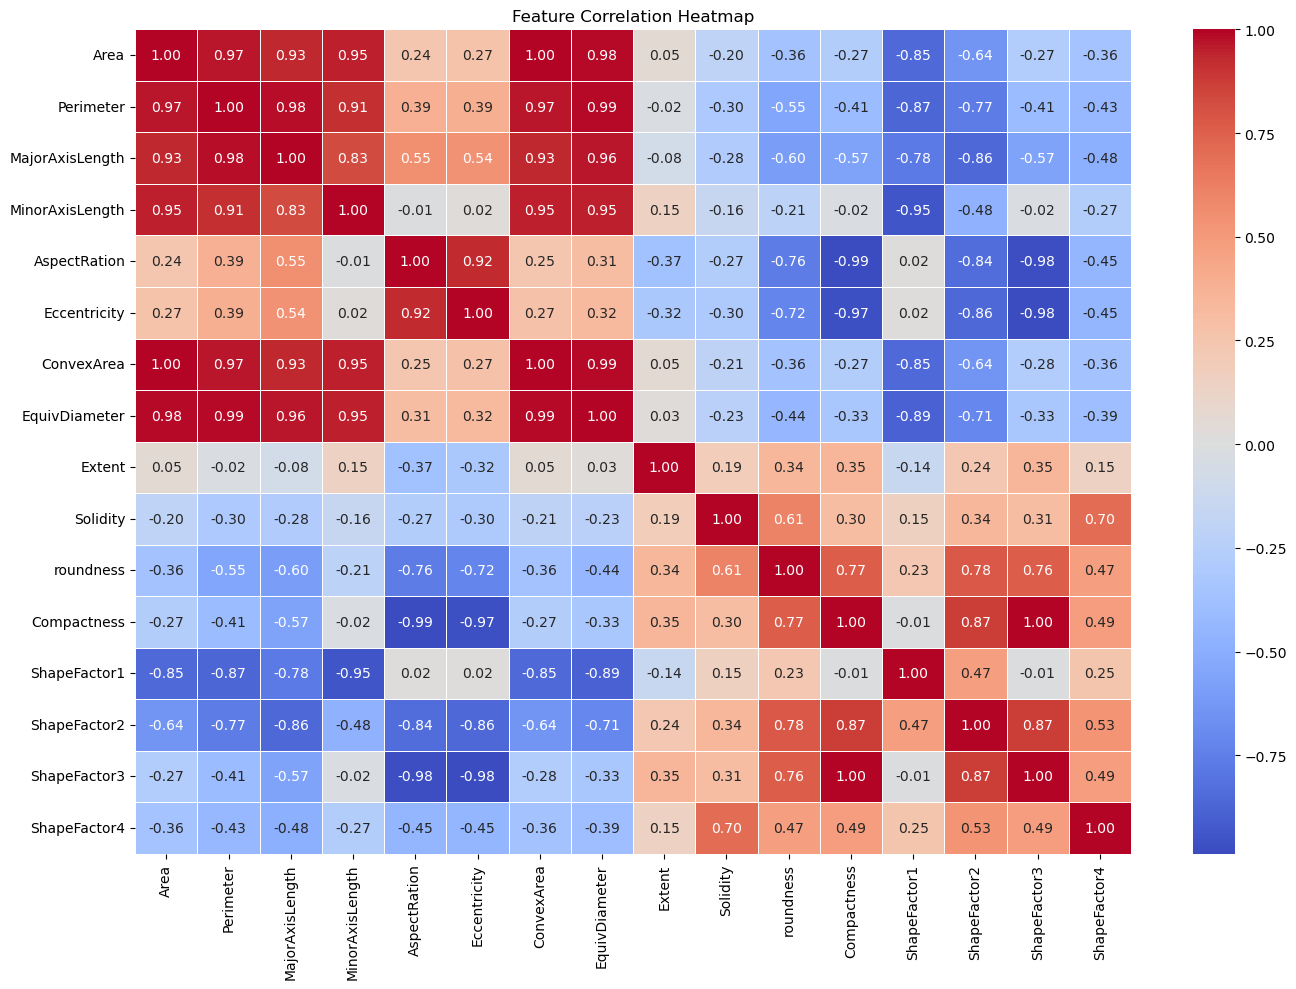

In [13]:
# Task 2: Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

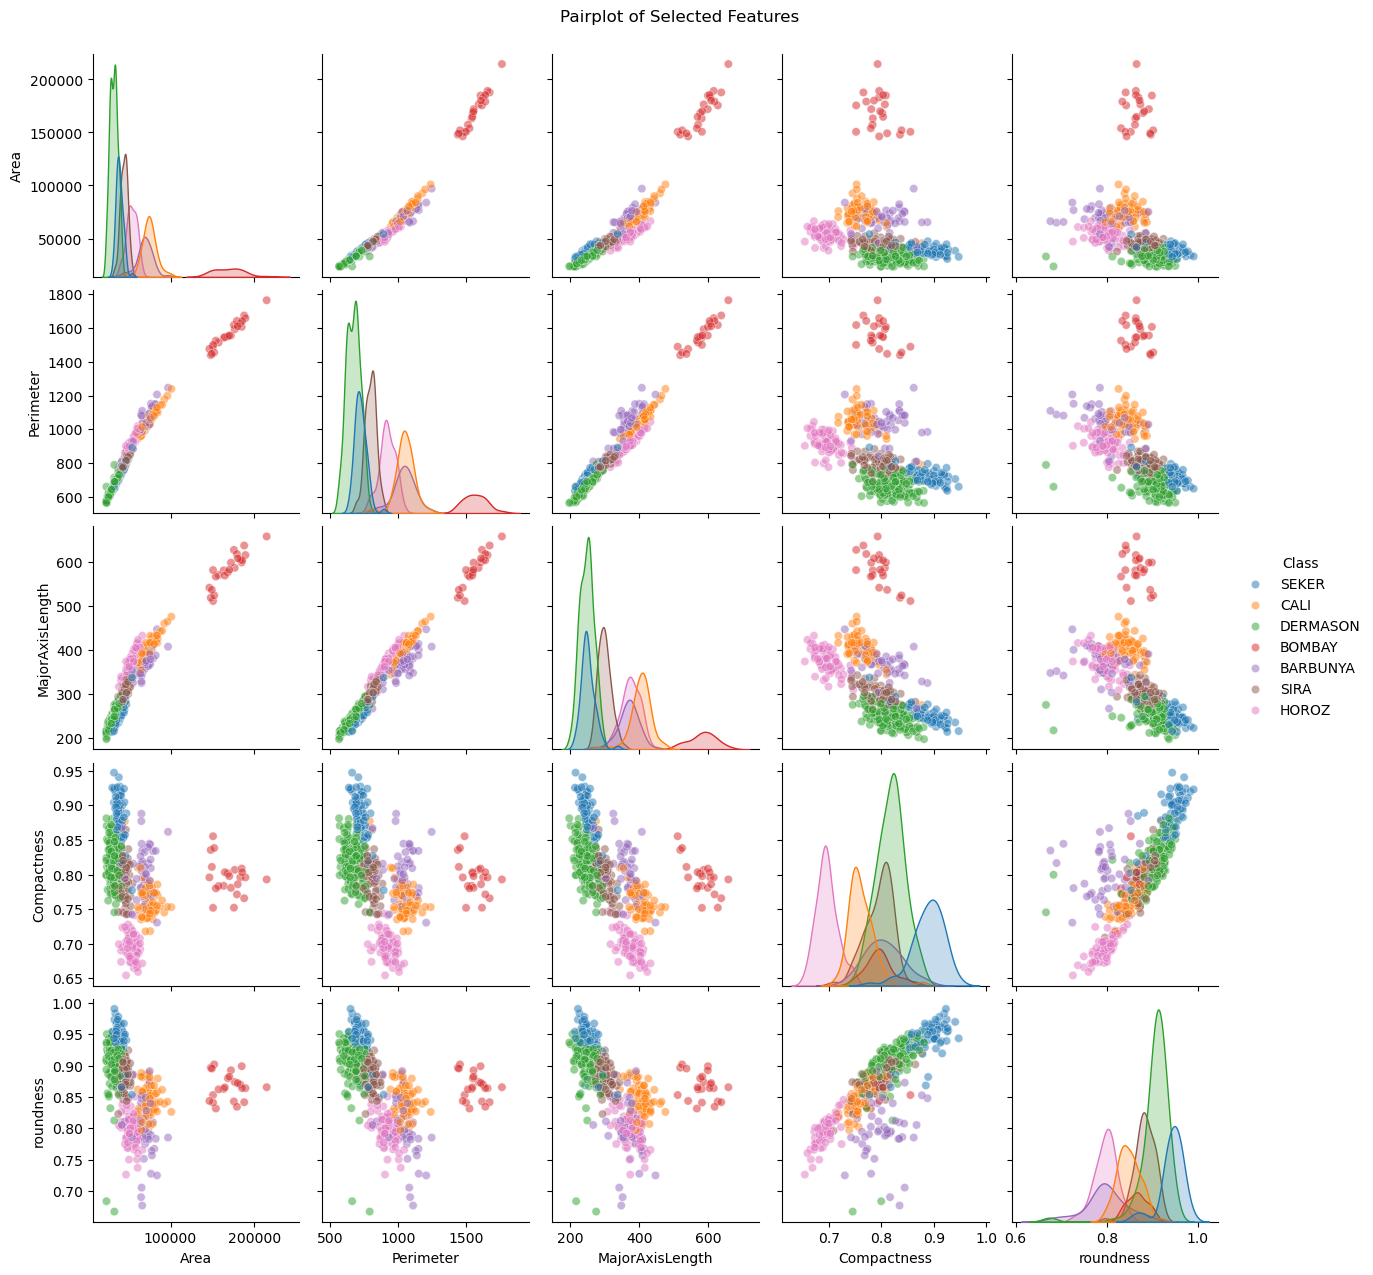

Key Findings:
- Area, Perimeter, MajorAxisLength are highly correlated (>0.98)
- Bombay beans are clearly separated from other classes
- ShapeFactor features have lower correlation with size features
- Mild class imbalance: Bombay is minority, Dermason is majority


In [14]:
# Task 2: Pairplot (using a sample for speed)
selected_cols = ['Area', 'Perimeter', 'MajorAxisLength', 'Compactness', 'roundness', 'Class']
sample_df = df[selected_cols].sample(500, random_state=42)
sns.pairplot(sample_df, hue='Class', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

print('Key Findings:')
print('- Area, Perimeter, MajorAxisLength are highly correlated (>0.98)')
print('- Bombay beans are clearly separated from other classes')
print('- ShapeFactor features have lower correlation with size features')
print('- Mild class imbalance: Bombay is minority, Dermason is majority')

## Task 3: Missing Values & Outlier Treatment

In [15]:
# Task 3: Check missing values
print('Missing Values per column:')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

Missing Values per column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total missing: 0


In [16]:
# Task 3: Outlier detection using IQR method
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {col: count_outliers_iqr(df[col]) for col in features}
print('Outlier counts per feature (IQR method):')
for col, cnt in outlier_counts.items():
    print(f'  {col}: {cnt}')

Outlier counts per feature (IQR method):
  Area: 551
  Perimeter: 500
  MajorAxisLength: 379
  MinorAxisLength: 567
  AspectRation: 485
  Eccentricity: 833
  ConvexArea: 549
  EquivDiameter: 526
  Extent: 271
  Solidity: 774
  roundness: 98
  Compactness: 124
  ShapeFactor1: 533
  ShapeFactor2: 0
  ShapeFactor3: 202
  ShapeFactor4: 760


In [17]:
# Task 3: Outlier treatment using IQR capping (winsorization)
df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print('Outlier treatment done (IQR capping/winsorization).')
print('Shape after treatment:', df_clean.shape)

Outlier treatment done (IQR capping/winsorization).
Shape after treatment: (13543, 17)


## Task 4: Feature Engineering & Preprocessing

In [18]:
# Task 4: Check skewness
skewness = df_clean[features].skew().sort_values(ascending=False)
print('Skewness of features:')
print(skewness)

# Apply log transform for highly skewed features (|skew| > 1)
high_skew = skewness[abs(skewness) > 1].index.tolist()
print(f'\nHighly skewed features (|skew|>1): {high_skew}')

for col in high_skew:
    if df_clean[col].min() > 0:
        df_clean[col] = np.log1p(df_clean[col])
print('Log transform applied to highly skewed features.')

Skewness of features:
MajorAxisLength    0.978854
ConvexArea         0.969221
Perimeter          0.966336
Area               0.962041
EquivDiameter      0.839585
MinorAxisLength    0.729091
AspectRation       0.470467
ShapeFactor2       0.294332
ShapeFactor3       0.191359
Compactness        0.017507
ShapeFactor1      -0.332581
roundness         -0.497000
Eccentricity      -0.614243
Extent            -0.782121
Solidity          -0.844469
ShapeFactor4      -1.039942
dtype: float64

Highly skewed features (|skew|>1): ['ShapeFactor4']
Log transform applied to highly skewed features.


In [19]:
# Task 4: Encode target label
le = LabelEncoder()
df_clean['Class_encoded'] = le.fit_transform(df_clean['Class'])
print('Classes:', le.classes_)
print('Encoded:', le.transform(le.classes_))

X = df_clean[features]
y = df_clean['Class_encoded']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size: {X_train.shape}, Test size: {X_test.shape}')
print('Stratified split ensures proportional class representation in both sets.')

Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Encoded: [0 1 2 3 4 5 6]

Train size: (10834, 16), Test size: (2709, 16)
Stratified split ensures proportional class representation in both sets.


## Task 5: Model Building with Multiple Classifiers

In [20]:
# Task 5: Define all classifiers using Pipelines (StandardScaler + Model)
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    'AdaBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', AdaBoostClassifier(random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
}
print('Pipelines defined for all classifiers.')

Pipelines defined for all classifiers.


In [21]:
# Task 5: Train all models and evaluate with cross-validation
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, pipeline.predict(X_train))
    test_acc = accuracy_score(y_test, pipeline.predict(X_test))
    test_f1 = f1_score(y_test, pipeline.predict(X_test), average='weighted')
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    overfit = 'Y' if (train_acc - test_acc) > 0.03 else 'N'
    results[name] = {
        'Train Acc': round(train_acc, 4),
        'Test Acc': round(test_acc, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'F1 Score': round(test_f1, 4),
        'Overfitting': overfit
    }
    print(f'{name}: Train={train_acc:.4f} | Test={test_acc:.4f} | CV={cv_scores.mean():.4f}(±{cv_scores.std():.4f}) | F1={test_f1:.4f}')
    
print('\nAll models trained successfully.')

Logistic Regression: Train=0.9266 | Test=0.9195 | CV=0.9247(±0.0030) | F1=0.9197
Decision Tree: Train=1.0000 | Test=0.8966 | CV=0.8972(±0.0051) | F1=0.8964
Random Forest: Train=1.0000 | Test=0.9214 | CV=0.9229(±0.0061) | F1=0.9212


  File "C:\Users\anith\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\anith\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anith\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anith\anaconda3\Lib\subprocess.

KNN: Train=0.9428 | Test=0.9110 | CV=0.9182(±0.0064) | F1=0.9112
SVM: Train=0.9344 | Test=0.9228 | CV=0.9306(±0.0046) | F1=0.9229
Gradient Boosting: Train=0.9632 | Test=0.9188 | CV=0.9275(±0.0058) | F1=0.9188
AdaBoost: Train=0.7789 | Test=0.7697 | CV=0.7931(±0.0178) | F1=0.7419
Naive Bayes: Train=0.8981 | Test=0.8992 | CV=0.8973(±0.0065) | F1=0.8994

All models trained successfully.


## Task 6: Handling Class Imbalance

In [22]:
# Task 6: Handle class imbalance using Random Oversampling (sklearn resample)
# Combine train features and labels
X_train_bal = X_train.copy()
X_train_bal['target'] = y_train.values

# Find majority class count
max_count = X_train_bal['target'].value_counts().max()

# Oversample minority classes
balanced_parts = []
for class_label in X_train_bal['target'].unique():
    subset = X_train_bal[X_train_bal['target'] == class_label]
    if len(subset) < max_count:
        subset = resample(subset, replace=True, n_samples=max_count, random_state=42)
    balanced_parts.append(subset)

df_balanced = pd.concat(balanced_parts)
X_train_res = df_balanced.drop('target', axis=1)
y_train_res = df_balanced['target']

print('Before oversampling:', y_train.value_counts().to_dict())
print('After oversampling:', y_train_res.value_counts().to_dict())
print(f'Train set size: {len(y_train)} -> {len(y_train_res)}')

Before oversampling: {3: 2837, 6: 2109, 5: 1621, 4: 1488, 2: 1304, 0: 1057, 1: 418}
After oversampling: {2: 2837, 0: 2837, 4: 2837, 6: 2837, 3: 2837, 5: 2837, 1: 2837}
Train set size: 10834 -> 19859


In [23]:
# Task 6: Retrain top models (SVM & Logistic Regression) on balanced data
for name in ['SVM', 'Logistic Regression']:
    pipeline = pipelines[name]
    pipeline.fit(X_train_res, y_train_res)
    test_acc = accuracy_score(y_test, pipeline.predict(X_test))
    test_f1 = f1_score(y_test, pipeline.predict(X_test), average='weighted')
    print(f'{name} (balanced) -> Test Acc: {test_acc:.4f} | F1: {test_f1:.4f}')

print('\nNote: Class weighting (class_weight="balanced") also available in sklearn models.')

# Retrain all models on original data for final comparison
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

SVM (balanced) -> Test Acc: 0.9206 | F1: 0.9208
Logistic Regression (balanced) -> Test Acc: 0.9173 | F1: 0.9176

Note: Class weighting (class_weight="balanced") also available in sklearn models.


## Task 7: Model Evaluation & Overfitting Check

In [24]:
# Task 7: Detailed evaluation for all models
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    print(f'\n=== {name} ===')
    print(f'Train Accuracy: {results[name]["Train Acc"]}')
    print(f'Test  Accuracy: {results[name]["Test Acc"]}')
    print(f'Overfitting   : {results[name]["Overfitting"]}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=le.classes_))


=== Logistic Regression ===
Train Accuracy: 0.9266
Test  Accuracy: 0.9195
Overfitting   : N
Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


=== Decision Tree ===
Train Accuracy: 1.0
Test  Accuracy: 0.8966
Overfitting   : Y
Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.91      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI     

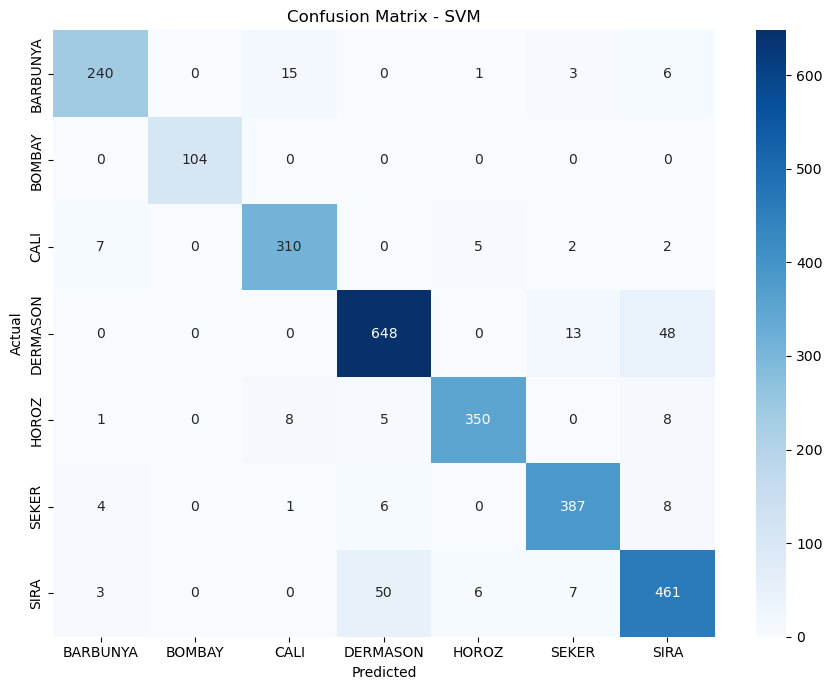

In [25]:
# Task 7: Confusion Matrix for SVM (best model)
best_model_name = 'SVM'
y_pred_best = pipelines[best_model_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Task 8: Hyperparameter Tuning

In [26]:
# Task 8: GridSearchCV on SVM (best model)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42))
])

param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_svm.fit(X_train, y_train)

print('Best SVM params:', grid_svm.best_params_)
print('Best CV Score:', round(grid_svm.best_score_, 4))
print('Tuned SVM Test Accuracy:', round(accuracy_score(y_test, grid_svm.predict(X_test)), 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Score: 0.9322
Tuned SVM Test Accuracy: 0.924


In [27]:
# Task 8: GridSearchCV on Logistic Regression (2nd best model)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'saga'],
    'model__multi_class': ['auto']
}

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print('Best LR params:', grid_lr.best_params_)
print('Best CV Score:', round(grid_lr.best_score_, 4))
print('Tuned LR Test Accuracy:', round(accuracy_score(y_test, grid_lr.predict(X_test)), 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best LR params: {'model__C': 10, 'model__multi_class': 'auto', 'model__solver': 'saga'}
Best CV Score: 0.9263
Tuned LR Test Accuracy: 0.9206


## Task 9: Model Comparison Table

In [37]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

comparison_results = []

# -----------------------------
# Pipeline Models (UPDATED)
# -----------------------------
for name, pipeline in pipelines.items():
    
    # Train pipeline
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Overfitting check
    gap = train_acc - test_acc
    overfit = "Y" if gap > 0.05 else "N"
    
    comparison_results.append([
        name,
        round(train_acc, 4),
        round(test_acc, 4),
        round(f1, 4),
        overfit
    ])

# -----------------------------
# Tuned Models (IMPORTANT)
# -----------------------------

# SVM Tuned (already pipeline-based if GridSearch used with Pipeline)
y_train_pred = grid_svm.predict(X_train)
y_test_pred = grid_svm.predict(X_test)

comparison_results.append([
    "SVM (Tuned)",
    round(accuracy_score(y_train, y_train_pred), 4),
    round(accuracy_score(y_test, y_test_pred), 4),
    round(f1_score(y_test, y_test_pred, average='weighted'), 4),
    "N"
])

# Logistic Regression Tuned
y_train_pred = grid_lr.predict(X_train)
y_test_pred = grid_lr.predict(X_test)

comparison_results.append([
    "Logistic Regression (Tuned)",
    round(accuracy_score(y_train, y_train_pred), 4),
    round(accuracy_score(y_test, y_test_pred), 4),
    round(f1_score(y_test, y_test_pred, average='weighted'), 4),
    "N"
])

# -----------------------------
# Create DataFrame
# -----------------------------
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "F1 Score",
        "Overfitting (Y/N)"
    ]
)

# Sort by F1 Score
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

# -----------------------------
# Best Model
# -----------------------------
best_model = comparison_df.iloc[0]

# -----------------------------
# Display Results
# -----------------------------
print("\nModel Comparison Table:\n")
print(comparison_df.to_string(index=False))

print("\nBest Model:")
print(best_model["Model"])


Model Comparison Table:

                      Model  Train Accuracy  Test Accuracy  F1 Score Overfitting (Y/N)
                SVM (Tuned)          0.9402         0.9240    0.9240                 N
                        SVM          0.9344         0.9228    0.9229                 N
              Random Forest          1.0000         0.9214    0.9212                 Y
Logistic Regression (Tuned)          0.9273         0.9206    0.9208                 N
        Logistic Regression          0.9266         0.9195    0.9197                 N
          Gradient Boosting          0.9632         0.9188    0.9188                 N
                        KNN          0.9428         0.9110    0.9112                 N
                Naive Bayes          0.8981         0.8992    0.8994                 N
              Decision Tree          1.0000         0.8966    0.8964                 Y
                   AdaBoost          0.7789         0.7697    0.7419                 N

Best Model:
SVM 

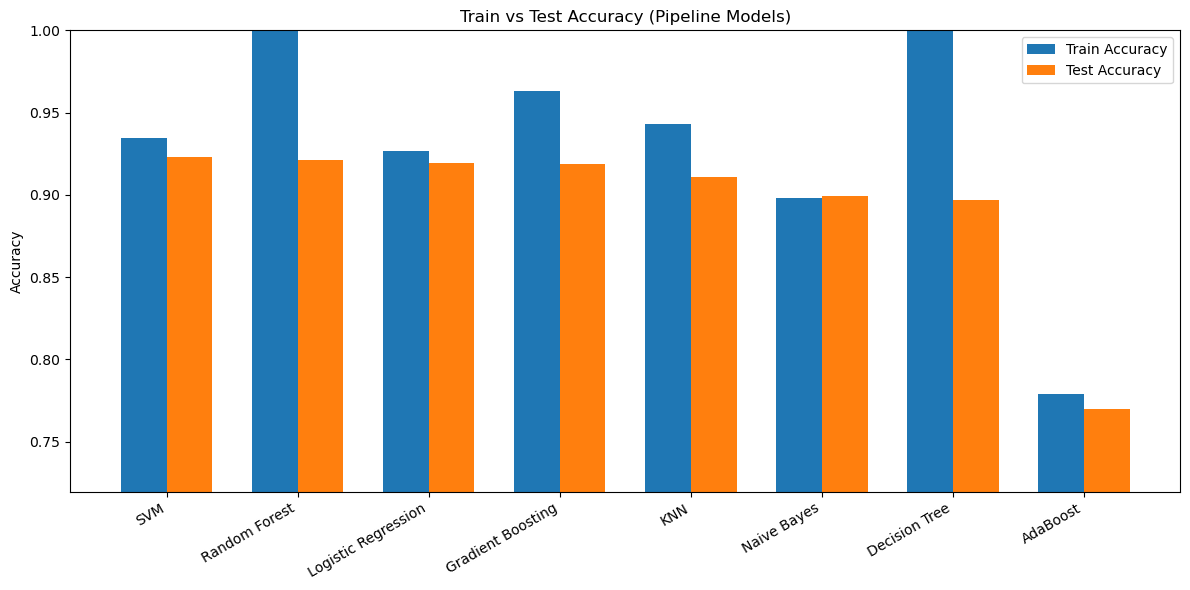


Best Model: SVM (Tuned)
Test Accuracy: 0.924
F1 Score: 0.924


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Filter ONLY Pipeline Models (exclude tuned)
# -----------------------------
plot_df = comparison_df[~comparison_df['Model'].str.contains('Tuned')].copy()

# Ensure numeric types (important)
plot_df['Train Accuracy'] = plot_df['Train Accuracy'].astype(float)
plot_df['Test Accuracy'] = plot_df['Test Accuracy'].astype(float)

# -----------------------------
# Bar Plot
# -----------------------------
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, plot_df['Train Accuracy'], width, label='Train Accuracy')
ax.bar(x + width/2, plot_df['Test Accuracy'], width, label='Test Accuracy')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=30, ha='right')

# Dynamic y-limit (better than fixed 0.8–1.0)
ax.set_ylim(min(plot_df['Test Accuracy']) - 0.05, 1.0)

ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Pipeline Models)')
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Best Model (from full table including tuned)
# -----------------------------
comparison_df['Test Accuracy'] = comparison_df['Test Accuracy'].astype(float)

best = comparison_df.loc[comparison_df['Test Accuracy'].idxmax()]

print(f"\nBest Model: {best['Model']}")
print(f"Test Accuracy: {best['Test Accuracy']}")
print(f"F1 Score: {best['F1 Score']}")

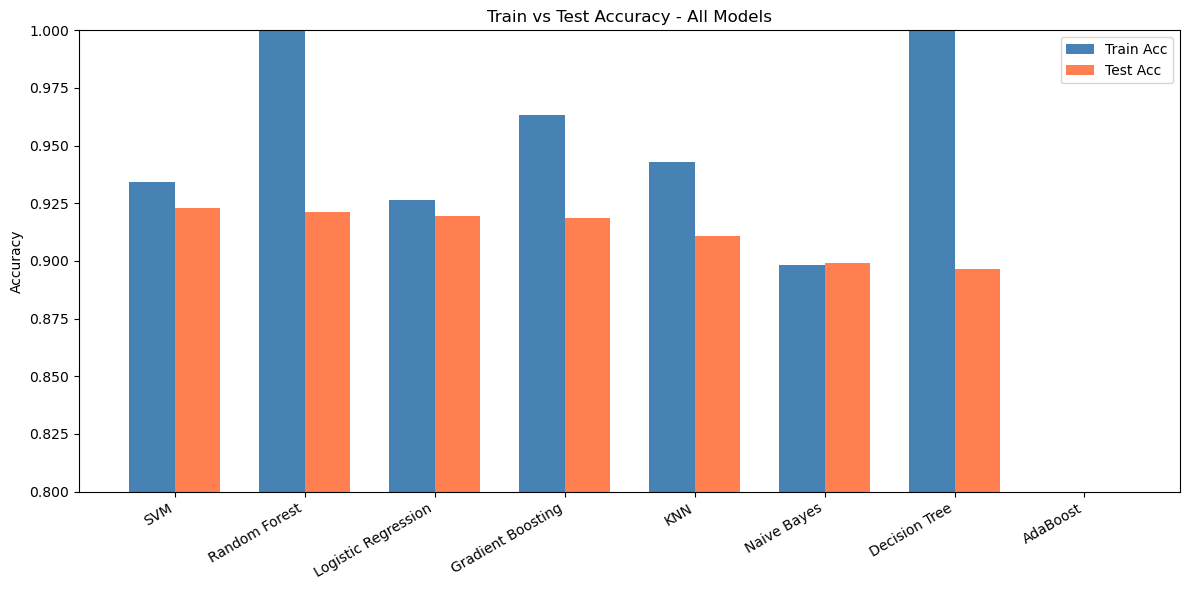


Best Model: Decision Tree | Test Accuracy: 0.8966 | F1: 0.8964


In [35]:
# Task 9: Visual comparison bar chart
plot_df = comparison_df[~comparison_df['Model'].str.contains('Tuned')].copy()

x = np.arange(len(plot_df))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, plot_df['Train Accuracy'].astype(float), width, label='Train Acc', color='steelblue')
ax.bar(x + width/2, plot_df['Test Accuracy'].astype(float), width, label='Test Acc', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=30, ha='right')
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy - All Models')
ax.legend()
plt.tight_layout()
plt.show()


## Save Best Model to Pickle

In [38]:
# Save the best model (tuned SVM) and label encoder to pickle
best_pipeline = grid_svm.best_estimator_

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Saved: best_model.pkl (Tuned SVM Pipeline)')
print('Saved: label_encoder.pkl')
print('Saved: feature_names.pkl')

# Verify load
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
print('\nVerification - Loaded model test accuracy:', round(accuracy_score(y_test, loaded_model.predict(X_test)), 4))

Saved: best_model.pkl (Tuned SVM Pipeline)
Saved: label_encoder.pkl
Saved: feature_names.pkl

Verification - Loaded model test accuracy: 0.924


# Build a Simple Classifier App